In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

X_train = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/CA_Moksit/train_input_Z61KlZo.csv")
y_train = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/CA_Moksit/train_output_DzPxaPY.csv")
X_test = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/CA_Moksit/test_input_5qJzHrr.csv")
y_pred_random = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/CA_Moksit/test_output_random.csv")

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")

<ipython-input-3-156f88f4fb15>:3: DtypeWarning: Columns (16,17,29,30,31,126,128,129,132,133,135,138,371) have mixed types. Specify dtype option on import or set low_memory=False.
  X_train = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/CA_Moksit/train_input_Z61KlZo.csv")
<ipython-input-3-156f88f4fb15>:5: DtypeWarning: Columns (16,17,29,30,31,126,128,129,132,133,135,138,371) have mixed types. Specify dtype option on import or set low_memory=False.
  X_test = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/CA_Moksit/test_input_5qJzHrr.csv")


Train: (383610, 374)
Test: (95852, 374)


In [4]:
from sklearn.model_selection import train_test_split

X_train_train, X_train_test, y_train_train, y_train_test = train_test_split(X_train, y_train, test_size=X_test.shape[0], random_state=42)

In [5]:
from sklearn.metrics import root_mean_squared_error

def rmse(y1, y2):
    return round(root_mean_squared_error(y1['CHARGE'], y2['CHARGE']), 2)

In [6]:
import matplotlib.pyplot as plt

def plot_bias(y_true, y_pred):
  target = 'CHARGE'
  try:
    y_true = y_true[target]
  except:
    pass
  try:
    y_pred = y_pred[target]
  except:
    pass

  plt.figure(figsize=(5, 5))
  plt.scatter(y_true, y_pred, alpha=0.5)
  plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
  plt.xlabel('Real')
  plt.ylabel('Predicted')
  plt.title('Bias')
  plt.grid(True)
  plt.show()

# Preprocessing

In [7]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

def preprocessing(X_train, X_test):
    # Save ID columns
    train_ids = X_train['ID']
    test_ids = X_test['ID']

    # separate columns + remove 'ID'
    num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
    num_cols.remove('ID')
    cat_cols = X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

    print(len(num_cols))
    print(len(cat_cols))

    # reduce size
    X_train[num_cols] = X_train[num_cols].astype("float32")
    X_test[num_cols] = X_test[num_cols].astype("float32")

    # mixed types -> strings only
    X_train[cat_cols] = X_train[cat_cols].astype(str)
    X_test[cat_cols] = X_test[cat_cols].astype(str)

    # pipelines
    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median'))
    ])
    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
    ])
    preprocessor = ColumnTransformer([
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])

    # fit transform
    X_train_clean = preprocessor.fit_transform(X_train)
    X_test_clean = preprocessor.transform(X_test)

    # Feature names
    all_features = num_cols + cat_cols

    # dataframes
    X_train_clean = pd.DataFrame(X_train_clean, columns=all_features, index=train_ids)
    X_test_clean = pd.DataFrame(X_test_clean, columns=all_features, index=test_ids)

    return X_train_clean, X_test_clean

In [8]:
# X_train_train_clean, X_train_test_clean = preprocessing(X_train_train, X_train_test)

# X_train_train_clean.to_csv('Data/X_train_train_clean.csv')
# X_train_test_clean.to_csv('Data/X_train_test_clean.csv')

import pandas as pd

X_train_train_clean = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/CA_Moksit/X_train_train_clean.csv', index_col='ID')
X_train_test_clean = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/CA_Moksit/X_train_test_clean.csv', index_col='ID')

# Zero

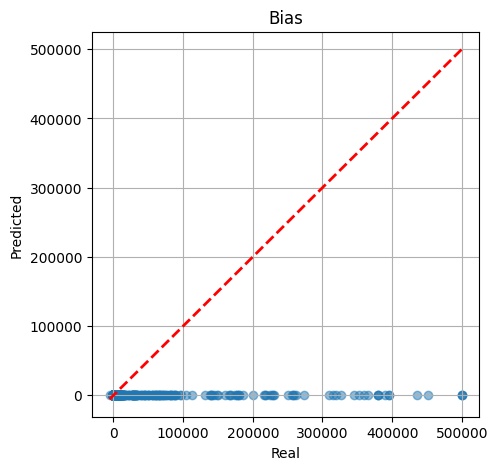

6837.83

In [ ]:
# local
y_train_pred_zero = y_train_test.copy()
y_train_pred_zero['CHARGE'] = 0

plot_bias(y_train_test, y_train_pred_zero)
rmse(y_train_test, y_train_pred_zero)

# Lasso

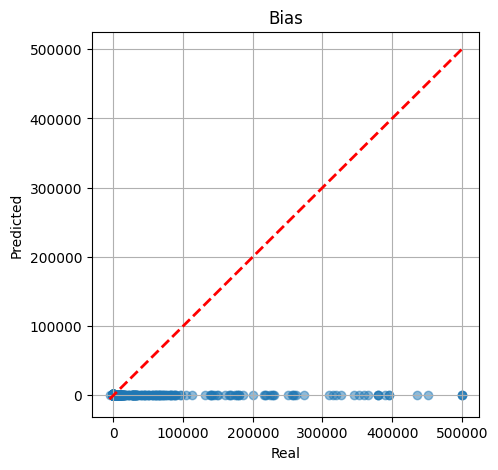

6832.36

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

y_train_pred_lasso = y_train_test.copy()

target = 'CHARGE'
y_train_col = y_train_train[target]

model = make_pipeline(
    StandardScaler(),
    Lasso(alpha=50, random_state=42)
)

model.fit(X_train_train_clean, y_train_col)
preds = model.predict(X_train_test_clean)
y_train_pred_lasso[target] = preds

plot_bias(y_train_test, y_train_pred_lasso)
rmse(y_train_test, y_train_pred_lasso)

# Hybrid Decision Tree

<ipython-input-28-06f85d7ae6c6>:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[763.20748232 763.20748232  10.52631579]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  y_train_pred_hdt.loc[test_non_zero_indices, target] = reg.predict(X_train_test_clean.loc[test_non_zero_indices])


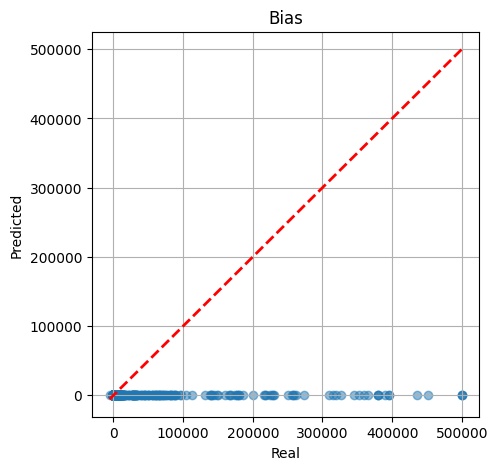

6837.74

In [ ]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

try:
  y_train_train = y_train_train.set_index('ID').copy()
  y_train_test = y_train_test.set_index('ID').copy()
except:
  pass

target = 'CHARGE'

# Step 1: Binary version of the target
y_train_target = y_train_train[[target]]
y_train_binary = (y_train_target != 0).astype(int)

# Step 2: Train Decision Tree Classifier
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train_train_clean, y_train_binary)

# Step 3: Predict binary labels for test set
binary_preds = clf.predict(X_train_test_clean)

# Step 4: Train Regressor on data where target != 0
non_zero_indices = y_train_binary[y_train_binary == 1].index
reg = DecisionTreeRegressor(max_depth=5, random_state=42)
reg.fit(X_train_train_clean.loc[non_zero_indices], y_train_target.loc[non_zero_indices])

# Step 5: Initialize predictions
y_train_pred_hdt = y_train_test.copy()
y_train_pred_hdt[target] = 0.0  # default prediction is 0

# Step 6: Apply regression only where classifier predicted 1
test_non_zero_indices = X_train_test_clean.index[binary_preds == 1]
y_train_pred_hdt.loc[test_non_zero_indices, target] = reg.predict(X_train_test_clean.loc[test_non_zero_indices])

y_train_pred_hdt = y_train_pred_hdt.reset_index()

plot_bias(y_train_test, y_train_pred_hdt)
rmse(y_train_test, y_train_pred_hdt)

# IdealClassifier + Random Forest

Percentage of zeros in training data: 99.38%
Percentage of zeros predicted by the classifier: 99.41%


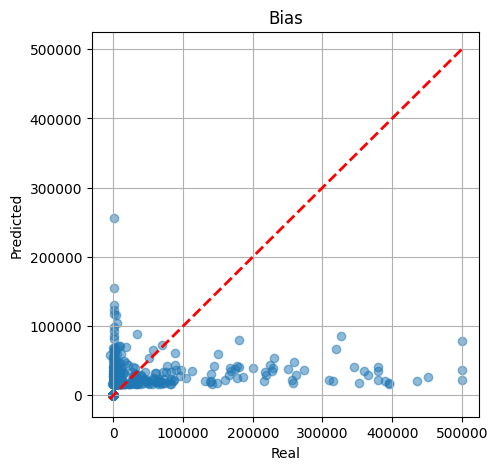

6399.96

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor

try:
    y_train_train = y_train_train.set_index('ID').copy()
    y_train_test = y_train_test.set_index('ID').copy()
except:
    pass

target = 'CHARGE'

# Step 1: Binary version of the target
y_train_target = y_train_train[[target]]
y_train_binary = (y_train_target != 0).astype(int)

# --> Print percentage of zeros in training set
train_percentage_zeros = np.mean(y_train_binary[target] == 0) * 100
print(f"Percentage of zeros in training data: {train_percentage_zeros:.2f}%")

# Step 2: Use leakage - perfect classifier using test target
y_train_test_binary = (y_train_test[[target]] != 0).astype(int)
binary_preds = y_train_test_binary.values.ravel()

# --> Print percentage of predicted zeros (now perfect)
percentage_zeros = np.mean(binary_preds == 0) * 100
print(f"Percentage of zeros predicted by the classifier: {percentage_zeros:.2f}%")

# Step 3: Train regressor only on non-zero training data
non_zero_indices = y_train_binary[y_train_binary[target] == 1].index
reg = RandomForestRegressor(max_depth=5, random_state=42)
reg.fit(X_train_train_clean.loc[non_zero_indices], y_train_target.loc[non_zero_indices].values.ravel())

# Step 4: Initialize predictions
y_train_pred_dtrf = y_train_test.copy()
y_train_pred_dtrf[target] = 0.0  # default prediction is 0

# Step 5: Use leakage-based classifier to predict non-zeros
test_non_zero_indices = y_train_test.index[binary_preds == 1]
y_train_pred_dtrf.loc[test_non_zero_indices, target] = reg.predict(X_train_test_clean.loc[test_non_zero_indices])

y_train_pred_dtrf = y_train_pred_dtrf.reset_index()

# Step 6: Evaluate
plot_bias(y_train_test, y_train_pred_dtrf)
rmse(y_train_test, y_train_pred_dtrf)

# Tweedie

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_glm/glm.py:285: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res)


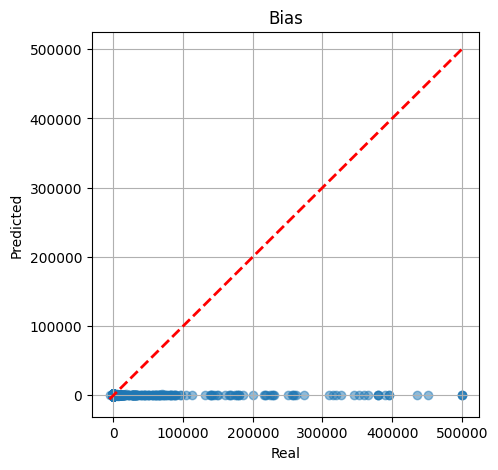

6832.69

In [ ]:
from sklearn.linear_model import TweedieRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

y_train_pred_tweedie = y_train_test.copy()

target = 'CHARGE'
y_train_col = np.abs(y_train_train[target])

model = TweedieRegressor()

model.fit(X_train_train_clean, y_train_col)
preds = model.predict(X_train_test_clean)
y_train_pred_tweedie[target] = preds

plot_bias(y_train_test, y_train_pred_tweedie)
rmse(y_train_test, y_train_pred_tweedie)

# Compare Models

| Model                       | RMSE    |
|----------------------------|---------|
| Zero                       | 6837.83 |
|----------------------------|---------|
| Lasso                      | 6832.36 |
| Tweedie                    | 6832.69 |
| Hybrid DecisionTree        | 6837.74 |